#### 3. Inactivity Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
lio_subs = pd.read_csv('LioCinema CSV files/subscribers.csv')
jotstar_subs = pd.read_csv('Jotstar CSV files/subscribers.csv')

In [3]:
# Add a identifer
lio_subs['platform'] = "LioCinema"
jotstar_subs['platform'] = "Jotstar"

In [4]:
# combine the datasets
combined_subscribers_df = pd.concat([lio_subs, jotstar_subs], ignore_index=True)

In [5]:
combined_subscribers_df.head()

,user_id,age_group,city_tier,subscription_date,subscription_plan,last_active_date,plan_change_date,new_subscription_plan,platform
0,UIDLC00000bea68a,25-34,Tier 3,2024-10-24,Free,NaN,NaN,NaN,LioCinema
1,UIDLC00009202848,18-24,Tier 1,2024-09-18,Basic,NaN,NaN,NaN,LioCinema
2,UIDLC0001086afc3,35-44,Tier 2,2024-03-23,Premium,NaN,2024-04-23,Free,LioCinema
3,UIDLC000186abd93,18-24,Tier 3,2024-09-07,Free,2024-10-23,NaN,NaN,LioCinema
4,UIDLC0002189b09f,18-24,Tier 2,2024-10-07,Premium,NaN,2024-11-07,Free,LioCinema


In [6]:
# Checking the dat atypes
combined_subscribers_df.dtypes

user_id                  object
age_group                object
city_tier                object
subscription_date        object
subscription_plan        object
last_active_date         object
plan_change_date         object
new_subscription_plan    object
platform                 object
dtype: object

In [7]:
# convert the subscription_date Column to datetime
combined_subscribers_df['subscription_date'] = pd.to_datetime(combined_subscribers_df['subscription_date'])

In [8]:
# Checking Data types again
combined_subscribers_df.dtypes

user_id                          object
age_group                        object
city_tier                        object
subscription_date        datetime64[ns]
subscription_plan                object
last_active_date                 object
plan_change_date                 object
new_subscription_plan            object
platform                         object
dtype: object

In [9]:
combined_subscribers_df.head()

,user_id,age_group,city_tier,subscription_date,subscription_plan,last_active_date,plan_change_date,new_subscription_plan,platform
0,UIDLC00000bea68a,25-34,Tier 3,2024-10-24,Free,NaN,NaN,NaN,LioCinema
1,UIDLC00009202848,18-24,Tier 1,2024-09-18,Basic,NaN,NaN,NaN,LioCinema
2,UIDLC0001086afc3,35-44,Tier 2,2024-03-23,Premium,NaN,2024-04-23,Free,LioCinema
3,UIDLC000186abd93,18-24,Tier 3,2024-09-07,Free,2024-10-23,NaN,NaN,LioCinema
4,UIDLC0002189b09f,18-24,Tier 2,2024-10-07,Premium,NaN,2024-11-07,Free,LioCinema


In [10]:
# Checking the null values
combined_subscribers_df.isnull().sum()

user_id                     0
age_group                   0
city_tier                   0
subscription_date           0
subscription_plan           0
last_active_date         1426
plan_change_date         1698
new_subscription_plan    1698
platform                    0
dtype: int64

In [11]:
# Convert dates to datetime
from datetime import datetime, timedelta
combined_subscribers_df['last_active_date'] = pd.to_datetime(combined_subscribers_df['last_active_date'])
current_date = pd.to_datetime('2024-11-30') 
combined_subscribers_df['is_inactive'] = (current_date - combined_subscribers_df['last_active_date']) > timedelta(days = 90)

In [12]:
combined_subscribers_df.head()

,user_id,age_group,city_tier,subscription_date,subscription_plan,last_active_date,plan_change_date,new_subscription_plan,platform,is_inactive
0,UIDLC00000bea68a,25-34,Tier 3,2024-10-24,Free,NaT,NaN,NaN,LioCinema,False
1,UIDLC00009202848,18-24,Tier 1,2024-09-18,Basic,NaT,NaN,NaN,LioCinema,False
2,UIDLC0001086afc3,35-44,Tier 2,2024-03-23,Premium,NaT,2024-04-23,Free,LioCinema,False
3,UIDLC000186abd93,18-24,Tier 3,2024-09-07,Free,2024-10-23,NaN,NaN,LioCinema,False
4,UIDLC0002189b09f,18-24,Tier 2,2024-10-07,Premium,NaT,2024-11-07,Free,LioCinema,False


In [13]:
# 3.1 Calculating the Overall Inactivity Rate

inactivity_rate = combined_subscribers_df.groupby('platform')['is_inactive'].mean() *100

<Axes: xlabel='platform'>

<Figure size 1200x600 with 0 Axes>

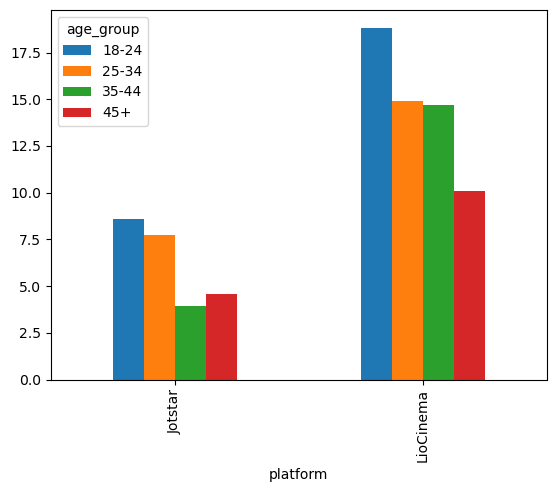

In [14]:
# 3.2 This Chart shows the inactivity rate for different age groups for each platform.
age_inactivity = combined_subscribers_df.groupby(['platform', 'age_group'])['is_inactive'].mean(). unstack()*100
plt.figure (figsize = (12,6))
age_inactivity.plot(kind = 'bar')

In [15]:
# 3.3 This Chart shows the inactivity rate for different city tier for each platform.
city_inactivity = combined_subscribers_df.groupby(['platform', 'city_tier'])['is_inactive'].mean(). unstack()*100
city_inactivity

city_tier,Tier 1,Tier 2,Tier 3
platform,,,
Jotstar,4.667864,9.206349,7.81250
LioCinema,13.122172,14.794521,18.84058


<Axes: xlabel='platform'>

<Figure size 1200x600 with 0 Axes>

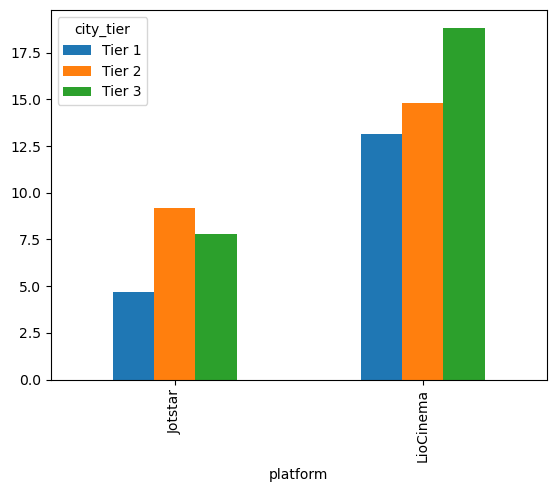

In [16]:
plt.figure (figsize = (12,6))
city_inactivity.plot(kind = 'bar')

In [17]:
# 3.4 This Chart shows the inactivity rate for Subscription Plans for each platform.

plan_inactivity = combined_subscribers_df.groupby(['platform', 'subscription_plan'])['is_inactive'].mean(). unstack()*100
plan_inactivity

subscription_plan,Basic,Free,Premium,VIP
platform,,,,
Jotstar,NaN,11.498258,2.990033,5.582524
LioCinema,12.802768,21.109123,3.947368,NaN


<Axes: xlabel='platform'>

<Figure size 1200x600 with 0 Axes>

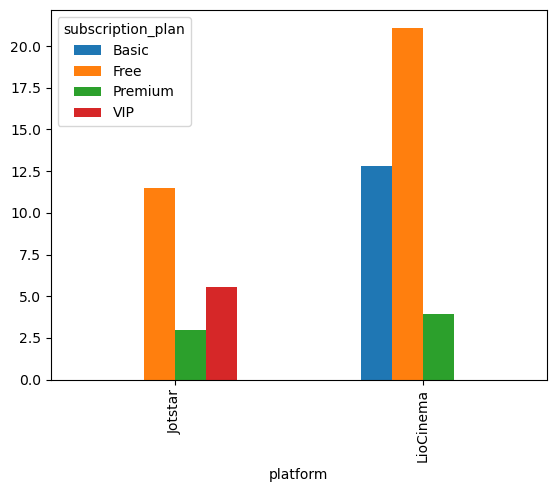

In [18]:
plt.figure (figsize = (12,6))
plan_inactivity.plot(kind = 'bar')